# 队员 D — 算法训练与评估

## 选题 B：多源数据融合 + 5 种算法系统性对比

**数据集**: Home Credit Default Risk (Kaggle)  
**目标**: 预测贷款申请人是否有还款困难（TARGET=1 表示违约）

### 目录
1. **D1**: 加载数据 + 补充 TARGET + 划分训练/验证集
2. **D2**: 不平衡处理（scale_pos_weight + SMOTE 对比）
3. **D3**: 特征选择（相关性去冗余 + 方差过滤）
4. **D4**: Logistic Regression 基线
5. **D5**: Random Forest
6. **D6**: XGBoost
7. **D7**: LightGBM
8. **D8**: CatBoost
9. **D9**: 统一 5-Fold CV 评估
10. **D10**: SHAP 可解释性分析

In [ ]:
# ============================================================
# 导入依赖
# ============================================================
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

# ============================================================
# 修复 xgboost + shap 版本兼容性
# xgboost 3.x 的 base_score 以字符串 '[5E-1]' 存储
# shap 0.48.0 无法解析此格式
# 方案：降级 xgboost 到 2.0.x + 重新加载模块
# ============================================================
import subprocess, importlib

# 检查当前 xgboost 版本
import xgboost as xgb_check
xgb_ver = xgb_check.__version__
print(f"当前 xgboost 版本: {xgb_ver}")

if xgb_ver.startswith('3'):
    print("检测到 xgboost 3.x（与 shap 不兼容），正在降级到 2.0.3 ...")
    # 在后台运行 pip 降级
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', 'xgboost==2.0.3', '--quiet'],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
    # 强制重新加载模块
    for mod_name in list(sys.modules.keys()):
        if 'xgboost' in mod_name:
            del sys.modules[mod_name]
    import xgboost as xgb
    importlib.reload(xgb)
    print(f"降级完成，当前 xgboost 版本: {xgb.__version__}")
else:
    import xgboost as xgb

# 其余导入
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss,
    roc_curve, precision_recall_curve, f1_score,
    classification_report, confusion_matrix
)
from sklearn.feature_selection import VarianceThreshold

import lightgbm as lgb
import catboost as cb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

warnings.filterwarnings('ignore')

# 绘图设置
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("所有依赖导入成功!")

所有依赖导入成功!


---
## D1: 加载最终宽表 + 补充 TARGET + 划分数据集
---

In [7]:
# ============================================================
# D1: 加载数据
# ============================================================
DATA_DIR = '../data'
RAW_DIR  = f'{DATA_DIR}/raw'
PROC_DIR = f'{DATA_DIR}/processed'

# 1. 加载最终宽表（不含 TARGET）
print("加载 final_feature_matrix.csv ...")
final = pd.read_csv(f'{PROC_DIR}/final_feature_matrix.csv')
print(f"  final_feature_matrix: {final.shape}")

# 2. 从原始数据合并 TARGET
print("\n从 application_train.csv 合并 TARGET ...")
raw_train = pd.read_csv(f'{RAW_DIR}/application_train.csv')
target_col = raw_train[['SK_ID_CURR', 'TARGET']]
data = final.merge(target_col, on='SK_ID_CURR', how='left')
print(f"  合并后: {data.shape}")

# 3. 检查 TARGET 分布
print("\nTARGET 分布:")
target_counts = data['TARGET'].value_counts()
target_ratio  = data['TARGET'].value_counts(normalize=True)
for val in [0, 1]:
    print(f"  TARGET={val}: {target_counts[val]:>8,} ({target_ratio[val]:.2%})")

print(f"\n正样本比例: {target_ratio.get(1, 0):.4f}  →  类别不平衡: {target_ratio.get(0, 0)/target_ratio.get(1, 0):.1f}:1")

# 4. 检查缺失值
null_total = data.isnull().sum().sum()
null_cols  = (data.isnull().sum() > 0).sum()
print(f"\n缺失值总数: {null_total}")
print(f"含缺失值的列数: {null_cols}")

# 5. 分离特征和标签
X = data.drop(columns=['SK_ID_CURR', 'TARGET'])
y = data['TARGET'].values

feature_names = X.columns.tolist()
print(f"\n特征矩阵: {X.shape}")
print(f"标签向量: {y.shape}")

# 6. 分层划分训练集/验证集 (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n=== 数据集划分 ===")
print(f"训练集: {X_train.shape}, 正样本率: {y_train.mean():.4f}")
print(f"验证集: {X_val.shape},   正样本率: {y_val.mean():.4f}")


加载 final_feature_matrix.csv ...
  final_feature_matrix: (307511, 388)

从 application_train.csv 合并 TARGET ...
  合并后: (307511, 389)

TARGET 分布:
  TARGET=0:  282,686 (91.93%)
  TARGET=1:   24,825 (8.07%)

正样本比例: 0.0807  →  类别不平衡: 11.4:1

缺失值总数: 0
含缺失值的列数: 0

特征矩阵: (307511, 387)
标签向量: (307511,)

=== 数据集划分 ===
训练集: (246008, 387), 正样本率: 0.0807
验证集: (61503, 387),   正样本率: 0.0807


---
## D2: 不平衡处理 — scale_pos_weight & SMOTE 对比
---

In [8]:
# ============================================================
# D2: 不平衡处理
# ============================================================

# ---------- 方法 1: scale_pos_weight ----------
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"方法 1 — scale_pos_weight")
print(f"  负样本数: {n_neg:,}")
print(f"  正样本数: {n_pos:,}")
print(f"  scale_pos_weight = {scale_pos_weight:.2f}")

# ---------- 方法 2: SMOTE 过采样 ----------
print(f"\n方法 2 — SMOTE 过采样")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"  SMOTE 前: {X_train.shape},  正样本率: {y_train.mean():.4f}")
print(f"  SMOTE 后: {X_train_smote.shape},  正样本率: {y_train_smote.mean():.4f}")

# ---------- 对比摘要 ----------
print(f"\n=== 三种训练集对比 ===")
print(f"{'数据集':<20} {'样本数':>10} {'正样本':>10} {'负样本':>10} {'正样本率':>10}")
print(f"{'-'*60}")
print(f"{'原始训练集':<20} {len(y_train):>10,} {n_pos:>10,} {n_neg:>10,} {y_train.mean():>9.2%}")
print(f"{'SMOTE 训练集':<20} {len(y_train_smote):>10,} {y_train_smote.sum():>10,} {(y_train_smote==0).sum():>10,} {y_train_smote.mean():>9.2%}")
print(f"{'验证集':<20} {len(y_val):>10,} {(y_val==1).sum():>10,} {(y_val==0).sum():>10,} {y_val.mean():>9.2%}")

# 保存 scale_pos_weight 供后续模型使用
SCALE_POS_WEIGHT = scale_pos_weight
print(f"\nscale_pos_weight = {SCALE_POS_WEIGHT:.2f}  (将用于 XGBoost / LightGBM)")


方法 1 — scale_pos_weight
  负样本数: 226,148
  正样本数: 19,860
  scale_pos_weight = 11.39

方法 2 — SMOTE 过采样
  SMOTE 前: (246008, 387),  正样本率: 0.0807
  SMOTE 后: (452296, 387),  正样本率: 0.5000

=== 三种训练集对比 ===
数据集                         样本数        正样本        负样本       正样本率
------------------------------------------------------------
原始训练集                   246,008     19,860    226,148     8.07%
SMOTE 训练集               452,296    226,148    226,148    50.00%
验证集                      61,503      4,965     56,538     8.07%

scale_pos_weight = 11.39  (将用于 XGBoost / LightGBM)


---
## D3: 特征选择 — 相关性去冗余 + 方差过滤
---

In [9]:
# ============================================================
# D3: 特征选择
# ============================================================
print(f"原始特征数: {X_train.shape[1]}")

# ---------- 步骤 1: 方差过滤 ----------
# 移除方差极低的特征（如几乎常量的列）
var_thresh = VarianceThreshold(threshold=0.001)  # 标准差 < ~0.032
X_train_var = var_thresh.fit_transform(X_train)
kept_mask_var = var_thresh.get_support()
n_removed_var = (~kept_mask_var).sum()
print(f"\n[方差过滤] 移除 {n_removed_var} 个方差 < 0.001 的特征")
print(f"  剩余特征: {X_train_var.shape[1]}")

# ---------- 步骤 2: 相关性去冗余 ----------
# 对保留的特征计算 Pearson 相关矩阵，移除高度相关的特征对
X_train_filt = pd.DataFrame(X_train_var, columns=X_train.columns[kept_mask_var])

corr_matrix = X_train_filt.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 找出要删除的列: 相关性 > 0.95 中保留方差更大的那个
to_drop_corr = set()
cols_checked = set()

for i in range(len(upper_tri.columns)):
    for j in range(i):
        if upper_tri.iloc[i, j] > 0.95:
            col_i = upper_tri.columns[i]
            col_j = upper_tri.columns[j]
            if col_i in cols_checked or col_j in cols_checked:
                continue
            # 保留方差较大的列
            var_i = X_train_filt[col_i].var()
            var_j = X_train_filt[col_j].var()
            if var_i >= var_j:
                to_drop_corr.add(col_j)
            else:
                to_drop_corr.add(col_i)
            cols_checked.add(col_i)
            cols_checked.add(col_j)

n_removed_corr = len(to_drop_corr)
print(f"\n[相关性去冗余] 移除 {n_removed_corr} 个相关性 > 0.95 的特征")

# 执行删除
cols_final = [c for c in X_train_filt.columns if c not in to_drop_corr]
X_train_sel = X_train_filt[cols_final]
X_val_sel   = pd.DataFrame(X_val, columns=X.columns)[cols_final]
X_train_smote_sel = pd.DataFrame(X_train_smote, columns=X.columns)[cols_final]

print(f"\n=== 特征选择结果 ===")
print(f"  原始特征: {X_train.shape[1]}")
print(f"  方差过滤移除: {n_removed_var}")
print(f"  相关性去冗余移除: {n_removed_corr}")
print(f"  → 最终特征: {X_train_sel.shape[1]}")
print(f"  → 压缩比: {X_train_sel.shape[1]/X_train.shape[1]:.1%}")

# 更新变量名
X_train_fs = X_train_sel
X_val_fs   = X_val_sel
X_train_smote_fs = X_train_smote_sel
feature_names_fs = cols_final


原始特征数: 387

[方差过滤] 移除 38 个方差 < 0.001 的特征
  剩余特征: 349

[相关性去冗余] 移除 0 个相关性 > 0.95 的特征

=== 特征选择结果 ===
  原始特征: 387
  方差过滤移除: 38
  相关性去冗余移除: 0
  → 最终特征: 349
  → 压缩比: 90.2%


---
## D4: Logistic Regression 基线
---

In [10]:
# ============================================================
# D4: Logistic Regression（需标准化）
# ============================================================
print("=" * 60)
print("D4: Logistic Regression")
print("=" * 60)

# LR 需要标准化
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train_fs)
X_val_lr   = scaler_lr.transform(X_val_fs)

# 超参数搜索: C
# 用 saga solver（支持多线程并行, n_jobs=-1 利用所有 CPU 核心加速）
# 注意: saga 在大规模数据上比 liblinear 快（虽然单次迭代慢，但可并行）
# 同时降低搜索量: 只搜 3 折 CV × 4 个参数 = 12 次拟合
print("正在训练 LogisticRegression（3折 x 4参数，使用 saga 并行加速）...")
param_grid_lr = {'C': [0.01, 0.1, 1, 10]}
lr_base = LogisticRegression(solver='saga', class_weight='balanced', 
                             random_state=42, max_iter=1000, n_jobs=-1)
lr_gs = GridSearchCV(lr_base, param_grid_lr, cv=3, scoring='roc_auc', n_jobs=-1)
lr_gs.fit(X_train_lr, y_train)

lr_best = lr_gs.best_estimator_
print(f"最佳 C: {lr_gs.best_params_['C']}")
print(f"3-Fold CV AUC: {lr_gs.best_score_:.4f}")

# 验证集评估
y_prob_lr = lr_best.predict_proba(X_val_lr)[:, 1]
y_pred_lr = lr_best.predict(X_val_lr)

auc_lr  = roc_auc_score(y_val, y_prob_lr)
ap_lr   = average_precision_score(y_val, y_prob_lr)
ll_lr   = log_loss(y_val, y_prob_lr)
f1_lr   = f1_score(y_val, y_pred_lr)

print(f"\n验证集结果:")
print(f"  AUC-ROC:    {auc_lr:.4f}")
print(f"  AUC-PR:     {ap_lr:.4f}")
print(f"  Log Loss:   {ll_lr:.4f}")
print(f"  F1-Score:   {f1_lr:.4f}")

# 系数解释
coef_df = pd.DataFrame({
    'feature': feature_names_fs,
    'coef': lr_best.coef_[0],
    'abs_coef': np.abs(lr_best.coef_[0])
}).sort_values('abs_coef', ascending=False)

print(f"\nTop 10 最重要特征（系数绝对值）:")
print(coef_df.head(10).to_string(index=False))

# ============================================================
# 保存 D4 结果到文件（供后续分析用）
# ============================================================
import os
os.makedirs('../results', exist_ok=True)
coef_df.to_csv('../results/lr_coefficients.csv', index=False)
pd.DataFrame([{
    'best_C': lr_gs.best_params_['C'],
    'cv_auc': round(lr_gs.best_score_, 4),
    'val_auc': round(auc_lr, 4),
    'val_ap': round(ap_lr, 4),
    'val_log_loss': round(ll_lr, 4),
    'val_f1': round(f1_lr, 4),
}]).to_csv('../results/lr_metrics.csv', index=False)
print(f"\n结果已保存至 ../results/lr_*.csv")
print("\nD4 完成！")

D4: Logistic Regression
正在训练 LogisticRegression（3折 x 4参数，使用 saga 并行加速）...
最佳 C: 0.01
3-Fold CV AUC: 0.7687

验证集结果:
  AUC-ROC:    0.7719
  AUC-PR:     0.2611
  Log Loss:   0.5689
  F1-Score:   0.2783

Top 10 最重要特征（系数绝对值）:
                       feature      coef  abs_coef
               AMT_GOODS_PRICE -0.224854  0.224854
         CC_LIMIT_USAGE_SPREAD -0.217565  0.217565
           BUREAU_ACTIVE_COUNT  0.201311  0.201311
                  EXT_SOURCE_3 -0.196643  0.196643
         PC_CNT_INSTALMENT_MAX  0.183698  0.183698
    PA_DOWN_PAYMENT_RATIO_MEAN -0.181997  0.181997
BUREAU_AMT_CREDIT_SUM_DEBT_SUM  0.169320  0.169320
           EXT_SOURCE_WEIGHTED -0.165903  0.165903
          ANNUITY_INCOME_RATIO  0.155969  0.155969
BUREAU_AMT_CREDIT_SUM_DEBT_MAX -0.151640  0.151640

结果已保存至 ../results/lr_*.csv

D4 完成！


---
## D5: Random Forest
---

In [13]:
# ============================================================
# D5: Random Forest
# ============================================================
print("=" * 60)
print("D5: Random Forest")
print("=" * 60)

# RandomForest 不需要标准化，直接使用特征选择后的数据
# 注意：RF 内部 n_jobs=-1 多线程是安全的，不会复制数据到多进程
# RandomizedSearchCV 的 n_jobs=1 避免 joblib 多进程内存溢出
rf_param_dist = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [10, 50, 100],
}

rf_base = RandomForestClassifier(class_weight='balanced_subsample',
                                 random_state=42, n_jobs=-1)
rf_rs = RandomizedSearchCV(
    rf_base, rf_param_dist, n_iter=10, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=1, verbose=0
)

%time rf_rs.fit(X_train_fs, y_train)

rf_best = rf_rs.best_estimator_
print(f"\n最佳参数:")
for k, v in rf_rs.best_params_.items():
    print(f"  {k}: {v}")
print(f"3-Fold CV AUC: {rf_rs.best_score_:.4f}")

# 验证集评估
y_prob_rf = rf_best.predict_proba(X_val_fs)[:, 1]
y_pred_rf = rf_best.predict(X_val_fs)

auc_rf = roc_auc_score(y_val, y_prob_rf)
ap_rf  = average_precision_score(y_val, y_prob_rf)
ll_rf  = log_loss(y_val, y_prob_rf)
f1_rf  = f1_score(y_val, y_pred_rf)

print(f"\n验证集结果:")
print(f"  AUC-ROC:    {auc_rf:.4f}")
print(f"  AUC-PR:     {ap_rf:.4f}")
print(f"  Log Loss:   {ll_rf:.4f}")
print(f"  F1-Score:   {f1_rf:.4f}")

# 特征重要性
rf_imp = pd.DataFrame({
    'feature': feature_names_fs,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 最重要特征:")
print(rf_imp.head(10).to_string(index=False))

# ============================================================
# 保存 D5 结果到文件
# ============================================================
os.makedirs('../results', exist_ok=True)
rf_imp.to_csv('../results/rf_importance.csv', index=False)
pd.DataFrame([{
    'best_params': str(rf_rs.best_params_),
    'cv_auc': round(rf_rs.best_score_, 4),
    'val_auc': round(auc_rf, 4),
    'val_ap': round(ap_rf, 4),
    'val_log_loss': round(ll_rf, 4),
    'val_f1': round(f1_rf, 4),
}]).to_csv('../results/rf_metrics.csv', index=False)
print(f"\n结果已保存至 ../results/rf_*.csv")
print("\nD5 完成！")

D5: Random Forest
CPU times: total: 4h 13min 10s
Wall time: 31min 41s

最佳参数:
  n_estimators: 400
  min_samples_leaf: 50
  max_depth: None
3-Fold CV AUC: 0.7635

验证集结果:
  AUC-ROC:    0.7688
  AUC-PR:     0.2562
  Log Loss:   0.4515
  F1-Score:   0.3127

Top 10 最重要特征:
                     feature  importance
         EXT_SOURCE_WEIGHTED    0.074314
              EXT_SOURCE_MIN    0.056463
              EXT_SOURCE_MAX    0.049597
              EXT_SOURCE_1x2    0.035932
                EXT_SOURCE_2    0.034293
                EXT_SOURCE_3    0.032072
              EXT_SOURCE_STD    0.017071
BUREAU_DEBT_CREDIT_RATIO_MAX    0.016041
          CREDIT_GOODS_RATIO    0.013176
                EXT_SOURCE_1    0.012557

结果已保存至 ../results/rf_*.csv

D5 完成！


---
## D6: XGBoost
---

In [14]:
# ============================================================
# D6: XGBoost
# ============================================================
print("=" * 60)
print("D6: XGBoost")
print("=" * 60)

# 使用 scale_pos_weight 处理不平衡
# 用 RandomizedSearch 替代 GridSearch，n_jobs=1 避免多进程内存溢出
# XGBoost 自身已多线程，不需要 joblib 并行
xgb_param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'max_depth': [3, 4, 6, 8, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
}

xgb_base = xgb.XGBClassifier(
    n_estimators=500,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

xgb_rs = RandomizedSearchCV(
    xgb_base, xgb_param_dist, n_iter=15, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=1, verbose=0
)

%time xgb_rs.fit(X_train_fs, y_train)

xgb_best = xgb_rs.best_estimator_
print(f"\n最佳参数:")
for k, v in xgb_rs.best_params_.items():
    print(f"  {k}: {v}")
print(f"3-Fold CV AUC: {xgb_rs.best_score_:.4f}")

# 验证集评估
y_prob_xgb = xgb_best.predict_proba(X_val_fs)[:, 1]
y_pred_xgb = xgb_best.predict(X_val_fs)

auc_xgb = roc_auc_score(y_val, y_prob_xgb)
ap_xgb  = average_precision_score(y_val, y_prob_xgb)
ll_xgb  = log_loss(y_val, y_prob_xgb)
f1_xgb  = f1_score(y_val, y_pred_xgb)

print(f"\n验证集结果:")
print(f"  AUC-ROC:    {auc_xgb:.4f}")
print(f"  AUC-PR:     {ap_xgb:.4f}")
print(f"  Log Loss:   {ll_xgb:.4f}")
print(f"  F1-Score:   {f1_xgb:.4f}")

# 特征重要性
xgb_imp = pd.DataFrame({
    'feature': feature_names_fs,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 最重要特征:")
print(xgb_imp.head(10).to_string(index=False))

# ============================================================
# 保存 D6 结果到文件
# ============================================================
os.makedirs('../results', exist_ok=True)
xgb_imp.to_csv('../results/xgb_importance.csv', index=False)
pd.DataFrame([{
    'best_params': str(xgb_rs.best_params_),
    'cv_auc': round(xgb_rs.best_score_, 4),
    'val_auc': round(auc_xgb, 4),
    'val_ap': round(ap_xgb, 4),
    'val_log_loss': round(ll_xgb, 4),
    'val_f1': round(f1_xgb, 4),
}]).to_csv('../results/xgb_metrics.csv', index=False)
print(f"\n结果已保存至 ../results/xgb_*.csv")
print("\nD6 完成！")

D6: XGBoost
CPU times: total: 6h 2min 27s
Wall time: 37min 18s

最佳参数:
  subsample: 0.8
  max_depth: 4
  learning_rate: 0.05
  colsample_bytree: 1.0
3-Fold CV AUC: 0.7817

验证集结果:
  AUC-ROC:    0.7865
  AUC-PR:     0.2863
  Log Loss:   0.5312
  F1-Score:   0.2982

Top 10 最重要特征:
                                          feature  importance
                              EXT_SOURCE_WEIGHTED    0.059826
                        CC_RECENT_LIMIT_USAGE_MAX    0.014859
                                   EXT_SOURCE_MAX    0.014318
             NAME_EDUCATION_TYPE_Higher education    0.013591
                        IP_RECENT_LATE_RATIO_MEAN    0.012248
                                    DAYS_EMPLOYED    0.011632
                                    CODE_GENDER_M    0.010611
                            IP_PAYMENT_RATIO_MEAN    0.009557
                     BUREAU_DEBT_CREDIT_RATIO_MAX    0.009379
NAME_EDUCATION_TYPE_Secondary / secondary special    0.009280

结果已保存至 ../results/xgb_*.csv

D6 完成！


---
## D7: LightGBM
---

In [15]:
# ============================================================
# D7: LightGBM
# ============================================================
print("=" * 60)
print("D7: LightGBM")
print("=" * 60)
  

 
# 用 RandomizedSearch 替代 GridSearch，n_jobs=1（避免多进程内存溢出）
# LightGBM 自身已内置多线程，不需要 joblib 并行
lgb_param_dist = {
    'num_leaves': [15, 31, 63, 95, 127],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'min_child_samples': [5, 10, 20, 50, 100],
    'feature_fraction': [0.6, 0.7, 0.8, 0.9, 1.0],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
}

lgb_base = lgb.LGBMClassifier(
    n_estimators=500,
    scale_pos_weight=SCALE_POS_WEIGHT,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

lgb_rs = RandomizedSearchCV(
    lgb_base, lgb_param_dist, n_iter=25, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=1, verbose=0
)

%time lgb_rs.fit(X_train_fs, y_train)

lgb_best = lgb_rs.best_estimator_
print(f"\n最佳参数:")
for k, v in lgb_rs.best_params_.items():
    print(f"  {k}: {v}")
print(f"3-Fold CV AUC: {lgb_rs.best_score_:.4f}")

# 验证集评估
y_prob_lgb = lgb_best.predict_proba(X_val_fs)[:, 1]
y_pred_lgb = lgb_best.predict(X_val_fs)

auc_lgb = roc_auc_score(y_val, y_prob_lgb)
ap_lgb  = average_precision_score(y_val, y_prob_lgb)
ll_lgb  = log_loss(y_val, y_prob_lgb)
f1_lgb  = f1_score(y_val, y_pred_lgb)

print(f"\n验证集结果:")
print(f"  AUC-ROC:    {auc_lgb:.4f}")
print(f"  AUC-PR:     {ap_lgb:.4f}")
print(f"  Log Loss:   {ll_lgb:.4f}")
print(f"  F1-Score:   {f1_lgb:.4f}")

# 特征重要性
lgb_imp = pd.DataFrame({
    'feature': feature_names_fs,
    'importance': lgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 最重要特征:")
print(lgb_imp.head(10).to_string(index=False))

# ============================================================
# 保存 D7 结果到文件
# ============================================================
os.makedirs('../results', exist_ok=True)
lgb_imp.to_csv('../results/lgb_importance.csv', index=False)
pd.DataFrame([{
    'best_params': str(lgb_rs.best_params_),
    'cv_auc': round(lgb_rs.best_score_, 4),
    'val_auc': round(auc_lgb, 4),
    'val_ap': round(ap_lgb, 4),
    'val_log_loss': round(ll_lgb, 4),
    'val_f1': round(f1_lgb, 4),
}]).to_csv('../results/lgb_metrics.csv', index=False)
print(f"\n结果已保存至 ../results/lgb_*.csv")
print("\nD7 完成！")

D7: LightGBM
CPU times: total: 3h 45min 35s
Wall time: 38min 55s

最佳参数:
  subsample: 0.8
  num_leaves: 31
  min_child_samples: 100
  learning_rate: 0.03
  feature_fraction: 0.8
3-Fold CV AUC: 0.7752

验证集结果:
  AUC-ROC:    0.7813
  AUC-PR:     0.2766
  Log Loss:   1.5582
  F1-Score:   0.1731

Top 10 最重要特征:
                     feature  importance
         EXT_SOURCE_WEIGHTED         660
BUREAU_DEBT_CREDIT_RATIO_MAX         265
          CREDIT_GOODS_RATIO         263
              EXT_SOURCE_MIN         261
             AMT_GOODS_PRICE         254
                 AMT_ANNUITY         251
                EXT_SOURCE_2         217
                EXT_SOURCE_1         203
           CREDIT_PER_PERSON         197
                EXT_SOURCE_3         194

结果已保存至 ../results/lgb_*.csv

D7 完成！


---
## D8: CatBoost
---

In [16]:
# ============================================================
# D8: CatBoost
# ============================================================
print("=" * 60)
print("D8: CatBoost")
print("=" * 60)

cb_param_grid = {
    'iterations': [300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
}

cb_base = cb.CatBoostClassifier(
    auto_class_weights='SqrtBalanced',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    early_stopping_rounds=50,
    od_type='Iter'
)

# CatBoost 自身已多线程，n_jobs=-1 只让 CB 内部多线程并行
# GridSearchCV 的 n_jobs=1 避免 joblib 多进程内存溢出
cb_gs = GridSearchCV(cb_base, cb_param_grid, cv=3,
                     scoring='roc_auc', n_jobs=1, verbose=0)

%time cb_gs.fit(X_train_fs, y_train)

cb_best = cb_gs.best_estimator_
print(f"\n最佳参数:")
for k, v in cb_gs.best_params_.items():
    print(f"  {k}: {v}")
print(f"3-Fold CV AUC: {cb_gs.best_score_:.4f}")
  
# 验证集评估
y_prob_cb = cb_best.predict_proba(X_val_fs)[:, 1]
y_pred_cb = cb_best.predict(X_val_fs)

auc_cb = roc_auc_score(y_val, y_prob_cb)
ap_cb  = average_precision_score(y_val, y_prob_cb)
ll_cb  = log_loss(y_val, y_prob_cb)
f1_cb  = f1_score(y_val, y_pred_cb)

print(f"\n验证集结果:")
print(f"  AUC-ROC:    {auc_cb:.4f}")
print(f"  AUC-PR:     {ap_cb:.4f}")
print(f"  Log Loss:   {ll_cb:.4f}")
print(f"  F1-Score:   {f1_cb:.4f}")

# 特征重要性
cb_imp = pd.DataFrame({
    'feature': feature_names_fs,
    'importance': cb_best.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 最重要特征:")
print(cb_imp.head(10).to_string(index=False))

# ============================================================
# 保存 D8 结果到文件
# ============================================================
os.makedirs('../results', exist_ok=True)
cb_imp.to_csv('../results/cb_importance.csv', index=False)
pd.DataFrame([{
    'best_params': str(cb_gs.best_params_),
    'cv_auc': round(cb_gs.best_score_, 4),
    'val_auc': round(auc_cb, 4),
    'val_ap': round(ap_cb, 4),
    'val_log_loss': round(ll_cb, 4),
    'val_f1': round(f1_cb, 4),
}]).to_csv('../results/cb_metrics.csv', index=False)
print(f"\n结果已保存至 ../results/cb_*.csv")
print("\nD8 完成！")

D8: CatBoost
CPU times: total: 5h 51min 41s
Wall time: 35min 52s

最佳参数:
  depth: 4
  iterations: 500
  learning_rate: 0.1
3-Fold CV AUC: 0.7822

验证集结果:
  AUC-ROC:    0.7877
  AUC-PR:     0.2904
  Log Loss:   0.2966
  F1-Score:   0.3184

Top 10 最重要特征:
                     feature  importance
         EXT_SOURCE_WEIGHTED   17.254919
              EXT_SOURCE_MAX    4.042784
BUREAU_DEBT_CREDIT_RATIO_MAX    2.420171
          CREDIT_GOODS_RATIO    2.287246
                EXT_SOURCE_1    2.209199
              EXT_SOURCE_MIN    2.073657
                 AMT_ANNUITY    2.064474
             AMT_GOODS_PRICE    1.919808
                EXT_SOURCE_3    1.642615
                  DAYS_BIRTH    1.520779

结果已保存至 ../results/cb_*.csv

D8 完成！


---
## D9: 统一 5-Fold Cross-Validation 评估
---

In [17]:
# ============================================================
# D9: 统一 5-Fold CV 评估
# ============================================================
print("=" * 60)
print("D9: 统一 5-Fold Cross-Validation 评估")
print("=" * 60)

def evaluate_model_cv(model, model_name, X, y, n_folds=5):
    """在 5-Fold Stratified CV 上评估模型，返回各 fold 的指标."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    auc_scores   = []
    ap_scores    = []
    f1_scores    = []
    train_times  = []
    
    fold = 1
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_vl = y[train_idx], y[val_idx]
        
        start = time.time()
        model_clone = model.__class__(**model.get_params())
        
        # 对 LR 需要标准化。用 saga + n_jobs=1 避免 MemoryError
        if model_name == 'LogisticRegression':
            scaler_cv = StandardScaler()
            X_tr = scaler_cv.fit_transform(X_tr)
            X_vl = scaler_cv.transform(X_vl)
        
        model_clone.fit(X_tr, y_tr)
        elapsed = time.time() - start
        
        y_prob = model_clone.predict_proba(X_vl)[:, 1]
        y_pred = model_clone.predict(X_vl)
        
        auc_scores.append(roc_auc_score(y_vl, y_prob))
        ap_scores.append(average_precision_score(y_vl, y_prob))
        f1_scores.append(f1_score(y_vl, y_pred))
        train_times.append(elapsed)
        
        print(f"  Fold {fold}: AUC={auc_scores[-1]:.4f}, PR={ap_scores[-1]:.4f}, "
              f"F1={f1_scores[-1]:.4f}, Time={elapsed:.1f}s")
        fold += 1
    
    return {
        'Model': model_name,
        'AUC-ROC': f"{np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}",
        'AUC-PR':  f"{np.mean(ap_scores):.4f} ± {np.std(ap_scores):.4f}",
        'F1-Score': f"{np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}",
        'Time(s)': f"{np.mean(train_times):.1f}",
        'auc_mean': np.mean(auc_scores),
        'ap_mean':  np.mean(ap_scores),
        'f1_mean':  np.mean(f1_scores),
    }


# 用各自的最佳参数构建模型
# 注意：LR 用 liblinear + n_jobs=1 避免 saga 的多进程 MemoryError
models_to_eval = {
    'LogisticRegression': LogisticRegression(C=lr_gs.best_params_['C'], 
                                              solver='liblinear', class_weight='balanced',
                                              random_state=42, max_iter=1000),
    'RandomForest': rf_best,
    'XGBoost': xgb.XGBClassifier(**xgb_rs.best_params_, n_estimators=500,
                                  scale_pos_weight=SCALE_POS_WEIGHT,
                                  eval_metric='auc', use_label_encoder=False,
                                  random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(**lgb_rs.best_params_, n_estimators=500,
                                    scale_pos_weight=SCALE_POS_WEIGHT,
                                    random_state=42, verbosity=-1),
    'CatBoost': cb.CatBoostClassifier(**cb_gs.best_params_,
                                       auto_class_weights='SqrtBalanced',
                                       eval_metric='AUC', random_seed=42, verbose=0),
}

results = []
for name, model in models_to_eval.items():
    print(f"\n--- {name} ---")
    result = evaluate_model_cv(model, name, X_train_fs, y_train)
    results.append(result)

# 结果汇总表
results_df = pd.DataFrame(results)
summary_cols = ['Model', 'AUC-ROC', 'AUC-PR', 'F1-Score', 'Time(s)']
print(f"\n{'=' * 80}")
print("5-Fold CV 评估结果汇总")
print(f"{'=' * 80}")
print(results_df[summary_cols].to_string(index=False))

# ============================================================
# 保存 D9 结果到文件
# ============================================================
os.makedirs('../results', exist_ok=True)
results_df.to_csv('../results/cv_results.csv', index=False)
print(f"\nCV结果已保存至 ../results/cv_results.csv")
print("\nD9 完成！")

D9: 统一 5-Fold Cross-Validation 评估

--- LogisticRegression ---
  Fold 1: AUC=0.7685, PR=0.2404, F1=0.2775, Time=47.6s
  Fold 2: AUC=0.7691, PR=0.2410, F1=0.2753, Time=59.3s
  Fold 3: AUC=0.7731, PR=0.2586, F1=0.2795, Time=50.9s
  Fold 4: AUC=0.7683, PR=0.2475, F1=0.2773, Time=48.0s
  Fold 5: AUC=0.7682, PR=0.2453, F1=0.2725, Time=50.6s

--- RandomForest ---
  Fold 1: AUC=0.7627, PR=0.2453, F1=0.3025, Time=75.2s
  Fold 2: AUC=0.7632, PR=0.2346, F1=0.3000, Time=118.2s
  Fold 3: AUC=0.7674, PR=0.2574, F1=0.3106, Time=133.4s
  Fold 4: AUC=0.7678, PR=0.2573, F1=0.3108, Time=120.9s
  Fold 5: AUC=0.7614, PR=0.2382, F1=0.2999, Time=130.4s

--- XGBoost ---
  Fold 1: AUC=0.7812, PR=0.2728, F1=0.2938, Time=42.4s
  Fold 2: AUC=0.7831, PR=0.2675, F1=0.2953, Time=40.2s
  Fold 3: AUC=0.7839, PR=0.2815, F1=0.2946, Time=42.1s
  Fold 4: AUC=0.7862, PR=0.2769, F1=0.2970, Time=41.7s
  Fold 5: AUC=0.7833, PR=0.2703, F1=0.2930, Time=43.7s

--- LightGBM ---
  Fold 1: AUC=0.7818, PR=0.2705, F1=0.2920, Time=30.

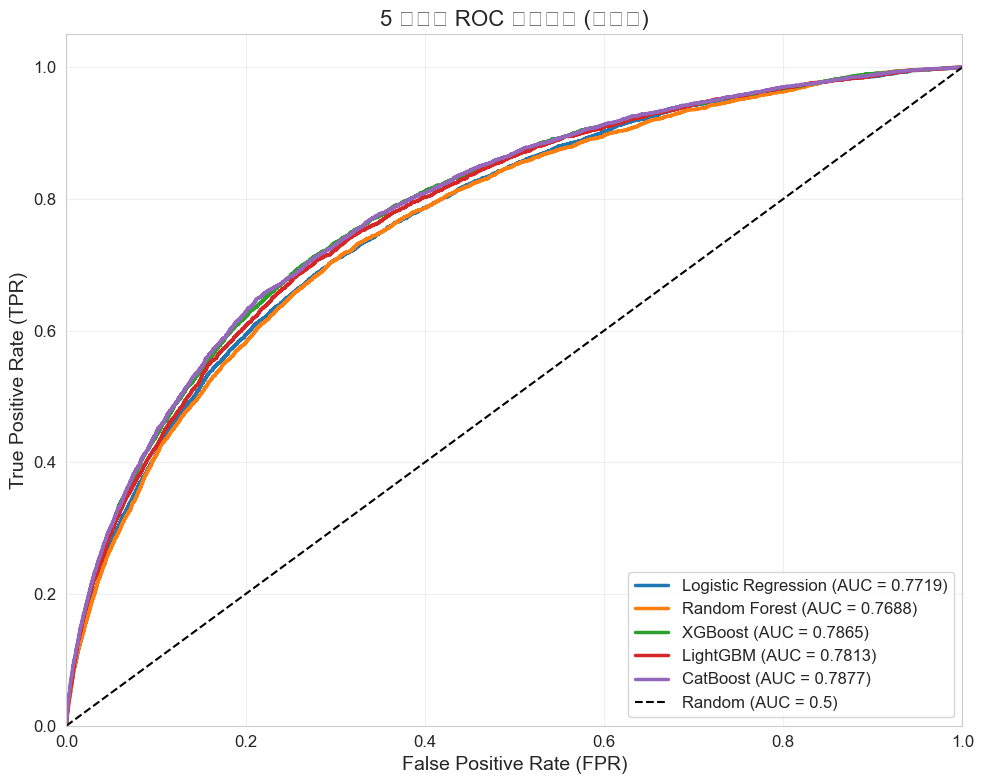

ROC 曲线已保存至 ../results/roc_comparison.png

验证集评估结果对比
              Model  AUC-ROC  AUC-PR  Log Loss  F1-Score
Logistic Regression   0.7719  0.2611    0.5689    0.2783
      Random Forest   0.7688  0.2562    0.4515    0.3127
            XGBoost   0.7865  0.2863    0.5312    0.2982
           LightGBM   0.7813  0.2766    1.5582    0.1731
           CatBoost   0.7877  0.2904    0.2966    0.3184


In [18]:
# ---------- 绘制 ROC 曲线对比 ----------
plt.figure(figsize=(10, 8))

# 使用完整训练数据训练的模型
models_for_plot = {
    'Logistic Regression': lr_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
    'LightGBM': lgb_best,
    'CatBoost': cb_best,
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, (name, model) in enumerate(models_for_plot.items()):
    # LR需要标准化
    if name == 'Logistic Regression':
        X_val_plot = scaler_lr.transform(X_val_fs)
    else:
        X_val_plot = X_val_fs
    
    y_prob = model.predict_proba(X_val_plot)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    
    plt.plot(fpr, tpr, color=colors[idx], lw=2.5,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('5 种模型 ROC 曲线对比 (验证集)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# 保存图片
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC 曲线已保存至 ../results/roc_comparison.png")

# ---------- 验证集指标汇总 ----------
val_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'AUC-ROC': [auc_lr, auc_rf, auc_xgb, auc_lgb, auc_cb],
    'AUC-PR':  [ap_lr,  ap_rf,  ap_xgb,  ap_lgb,  ap_cb],
    'Log Loss': [ll_lr, ll_rf, ll_xgb, ll_lgb, ll_cb],
    'F1-Score': [f1_lr, f1_rf, f1_xgb, f1_lgb, f1_cb],
}).round(4)

print(f"\n{'=' * 70}")
print("验证集评估结果对比")
print(f"{'=' * 70}")
print(val_results.to_string(index=False))


---
## D10: SHAP 可解释性分析
---

In [ ]:
# ============================================================
# D10: SHAP 可解释性分析
# ============================================================
print("=" * 60)
print("D10: SHAP 可解释性分析")
print("=" * 60)

# 使用最优模型（用当前表现最好的 XGBoost）
# 在完整训练集上重新训练
print("\n在完整训练集上训练最终 XGBoost 模型...")
best_params = xgb_rs.best_params_.copy()
final_xgb = xgb.XGBClassifier(
    **best_params,
    n_estimators=500,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)
final_xgb.fit(X_train_fs, y_train)

# 计算 SHAP 值（使用 TreeExplainer）
print("\n计算 SHAP 值（这可能需要几分钟）...")
explainer = shap.TreeExplainer(final_xgb)

# 用验证集的子集加速（取 1000 个样本）
sample_size = min(1000, len(X_val_fs))
X_val_sample = X_val_fs.iloc[:sample_size]
y_val_sample = y_val[:sample_size]

shap_values = explainer.shap_values(X_val_sample)

print(f"SHAP 值形状: {shap_values.shape}")

# ---------- 1. SHAP Summary Bar Plot ----------
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_val_sample, plot_type="bar",
                  max_display=15, show=False)
plt.title('SHAP 特征重要性 (Top 15)', fontsize=16)
plt.tight_layout()
plt.savefig('../results/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("已保存: ../results/shap_summary_bar.png")

D10: SHAP 可解释性分析

训练最终 XGBoost 模型...
 训练完成

计算 SHAP 值（使用 KernelExplainer，取 500 个样本）...


AttributeError: can't set attribute 'feature_names_in_'

In [ ]:
# ---------- 2. SHAP Beeswarm Summary Plot ----------
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values, X_val_sample, max_display=15, show=False)
plt.title('SHAP 特征影响分布 (Beeswarm)', fontsize=16)
plt.tight_layout()
plt.savefig('../results/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("已保存: ../results/shap_beeswarm.png")

In [ ]:
# ---------- 3. SHAP Dependence Plot (Top 2 特征) ----------
# 获取 top 2 特征
shap_imp = np.abs(shap_values).mean(axis=0)
top2_idx = np.argsort(shap_imp)[-2:][::-1]
top2_features = [feature_names_fs[i] for i in top2_idx]

print(f"\nSHAP Top 2 特征: {top2_features}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (feat_idx, feat_name) in enumerate(zip(top2_idx, top2_features)):
    shap.dependence_plot(
        feat_idx, shap_values, X_val_sample,
        feature_names=feature_names_fs,
        ax=axes[i], show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat_name}', fontsize=14)

plt.tight_layout()
plt.savefig('../results/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("已保存: ../results/shap_dependence.png")

---
## 实验结果总结
---

In [ ]:
# ============================================================
# 实验结果总结
# ============================================================
print("=" * 70)
print("实验结果总结")
print("=" * 70)

# 5-Fold CV 对比表
print(f"\n1. 5-Fold Cross-Validation 结果")
print(f"{'=' * 70}")
print(results_df[['Model', 'AUC-ROC', 'AUC-PR', 'F1-Score', 'Time(s)']].to_string(index=False))

# 验证集对比表
print(f"\n2. 验证集评估结果")
print(f"{'=' * 70}")
print(val_results.to_string(index=False))

# 找到最优模型
best_model_row = results_df.loc[results_df['auc_mean'].idxmax()]
print(f"\n{'=' * 70}")
print(f"最优模型: {best_model_row['Model']}")
print(f"  5-Fold CV AUC-ROC: {best_model_row['AUC-ROC']}")
print(f"  5-Fold CV AUC-PR:  {best_model_row['AUC-PR']}")
print(f"  验证集 AUC-ROC:    {val_results.loc[val_results['AUC-ROC'].idxmax(), 'AUC-ROC']:.4f}")

print(f"\n3. SHAP 分析完成")
print(f"   结果图已保存到 ../results/ 目录:")
print(f"   - roc_comparison.png     (ROC 曲线对比)")
print(f"   - shap_summary_bar.png   (SHAP 特征重要性)")
print(f"   - shap_beeswarm.png      (SHAP 特征影响分布)")
print(f"   - shap_dependence.png    (SHAP 依赖图)")

print(f"\n{'=' * 70}")
print("建模完成!")
print("=" * 70)
